In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install rasterio

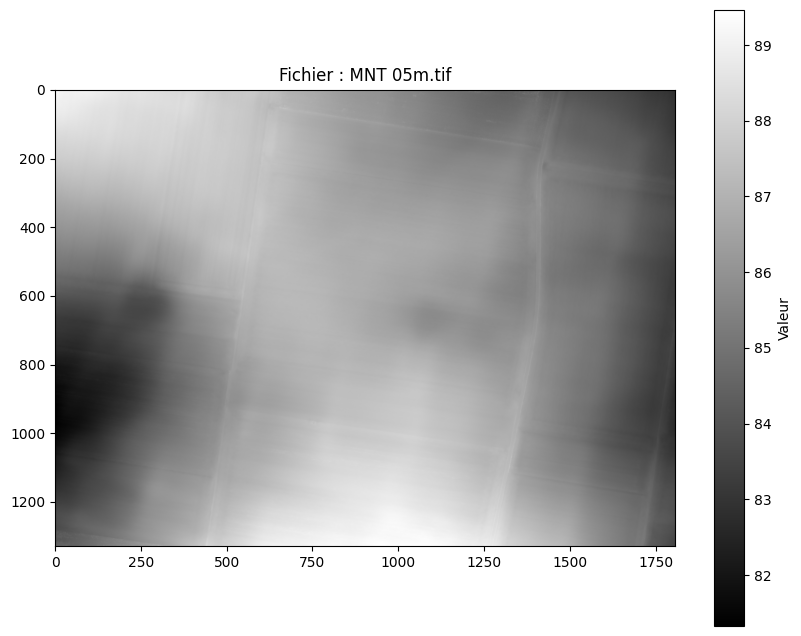

Info MNT 05m.tif: Taille 1806x1330, CRS: COMPD_CS["RGF93 Lambert 93 et NGF-IGN 1969",PROJCS["RGF93 Lambert 93 et NGF-IGN 1969",GEOGCS["RGF93 geographiques (dms)",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["NGF-IGN 1969",VERT_DATUM["unknown",2005],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Up",UP]]]



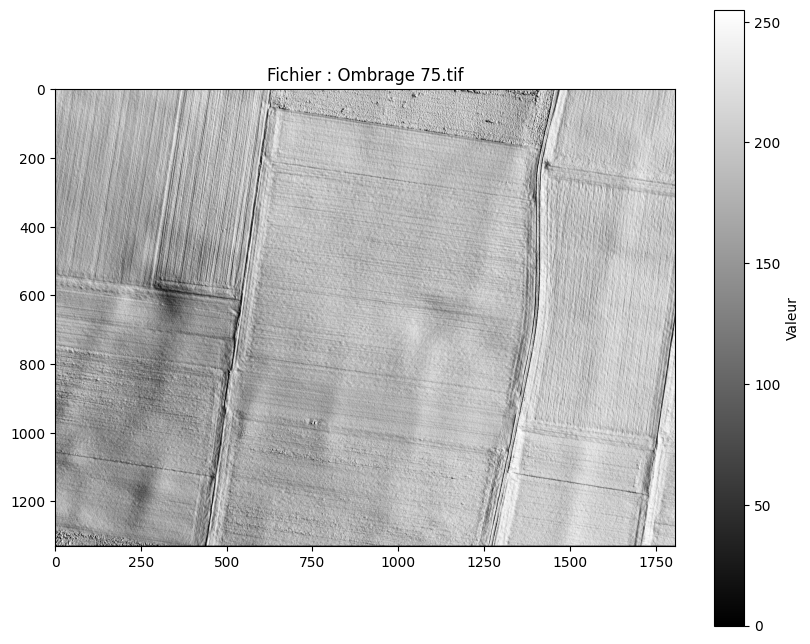

Info Ombrage 75.tif: Taille 1806x1330, CRS: COMPD_CS["RGF93 Lambert 93 et NGF-IGN 1969",PROJCS["RGF93 Lambert 93 et NGF-IGN 1969",GEOGCS["RGF93 geographiques (dms)",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["NGF-IGN 1969",VERT_DATUM["Nivellement General de la France - IGN69",2005,AUTHORITY["EPSG","5119"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Up",UP]]]



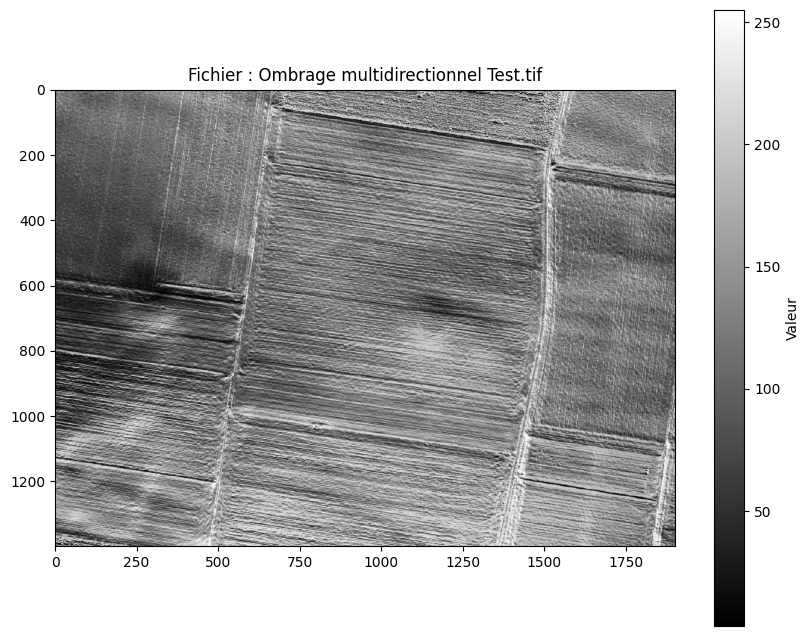

Info Ombrage multidirectionnel Test.tif: Taille 1900x1399, CRS: IGNF:LAMB93



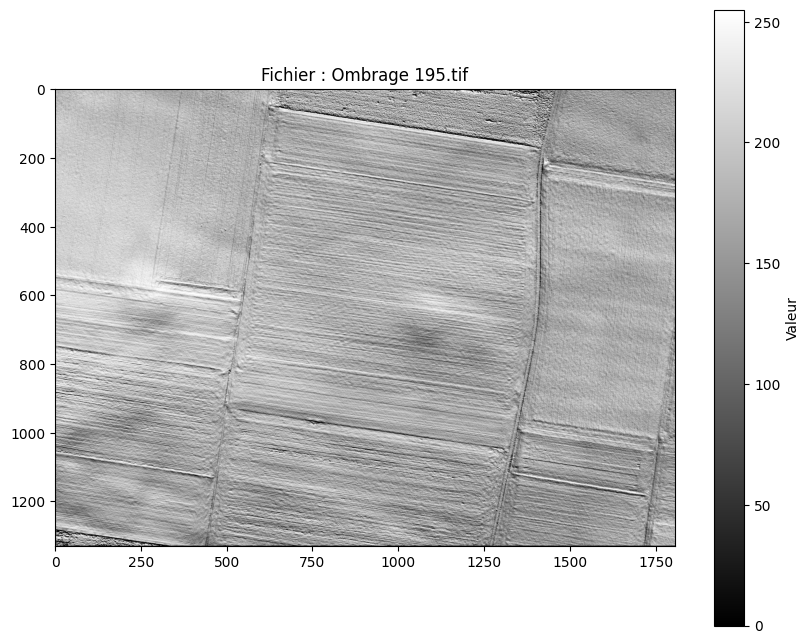

Info Ombrage 195.tif: Taille 1806x1330, CRS: COMPD_CS["RGF93 Lambert 93 et NGF-IGN 1969",PROJCS["RGF93 Lambert 93 et NGF-IGN 1969",GEOGCS["RGF93 geographiques (dms)",DATUM["Reseau_Geodesique_Francais_1993_v1",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6171"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",46.5],PARAMETER["central_meridian",3],PARAMETER["standard_parallel_1",44],PARAMETER["standard_parallel_2",49],PARAMETER["false_easting",700000],PARAMETER["false_northing",6600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]],VERT_CS["NGF-IGN 1969",VERT_DATUM["Nivellement General de la France - IGN69",2005,AUTHORITY["EPSG","5119"]],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Up",UP]]]



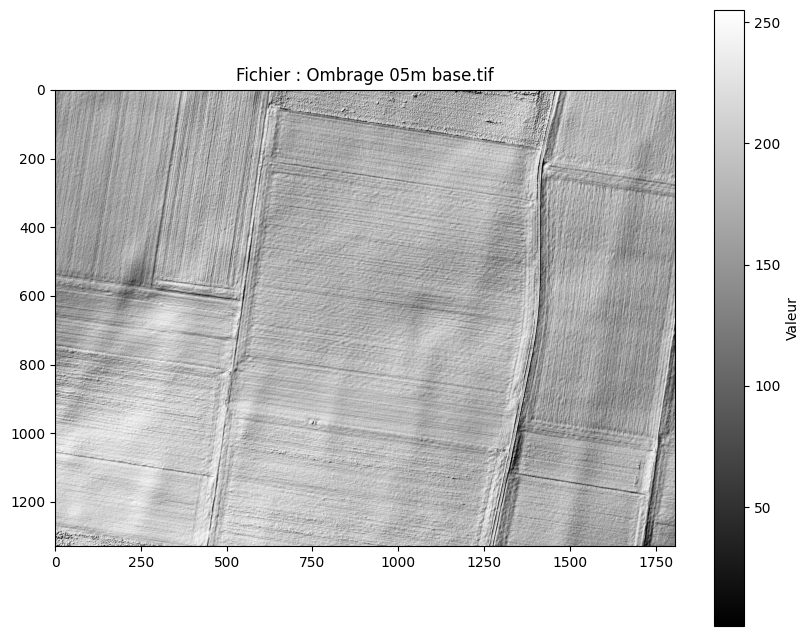

Info Ombrage 05m base.tif: Taille 1806x1330, CRS: IGNF:LAMB93



In [5]:
import rasterio
import matplotlib.pyplot as plt
import os

# Chemin vers le dossier (défini précédemment)
folder_path = '/content/drive/MyDrive/Datasets/Gauthier_Cerema/Premier_test'

# Récupérer la liste des fichiers .tif
tif_files = [f for f in os.listdir(folder_path) if f.endswith('.tif')]

for file_name in tif_files:
    file_path = os.path.join(folder_path, file_name)

    try:
        with rasterio.open(file_path) as src:
            # Lire la première bande (band 1)
            data = src.read(1)

            plt.figure(figsize=(10, 8))

            # Affichage en nuances de gris comme demandé
            img_plot = plt.imshow(data, cmap='gray')
            plt.colorbar(img_plot, label='Valeur')

            plt.title(f"Fichier : {file_name}")
            plt.axis('on') # Afficher les axes pixel
            plt.show()

            print(f"Info {file_name}: Taille {src.width}x{src.height}, CRS: {src.crs}\n")

    except Exception as e:
        print(f"Impossible de lire {file_name} : {e}")

In [2]:
import os

# Chemin vers le dossier spécifié
folder_path = '/content/drive/MyDrive/Datasets/Gauthier_Cerema/Premier_test'

# Vérifier si le dossier existe et lister son contenu
if os.path.exists(folder_path):
    print(f"Contenu du dossier '{folder_path}':")
    files = os.listdir(folder_path)
    for file_name in files:
        print(file_name)
else:
    print(f"Le dossier '{folder_path}' n'a pas été trouvé. Assurez-vous que le chemin est correct sur votre Drive.")

Contenu du dossier '/content/drive/MyDrive/Datasets/Gauthier_Cerema/Premier_test':
MNT 05m.tif
Ombrage 75.tif
Ombrage 195.tif.aux.xml
Ombrage multidirectionnel Test.tif
Ombrage 75.tif.aux.xml
Ombrage 195.tif
Ombrage 05m base.tif
MNT 05m.tif.aux.xml


Calcul du filtre de Frangi avec σ = 30 ...



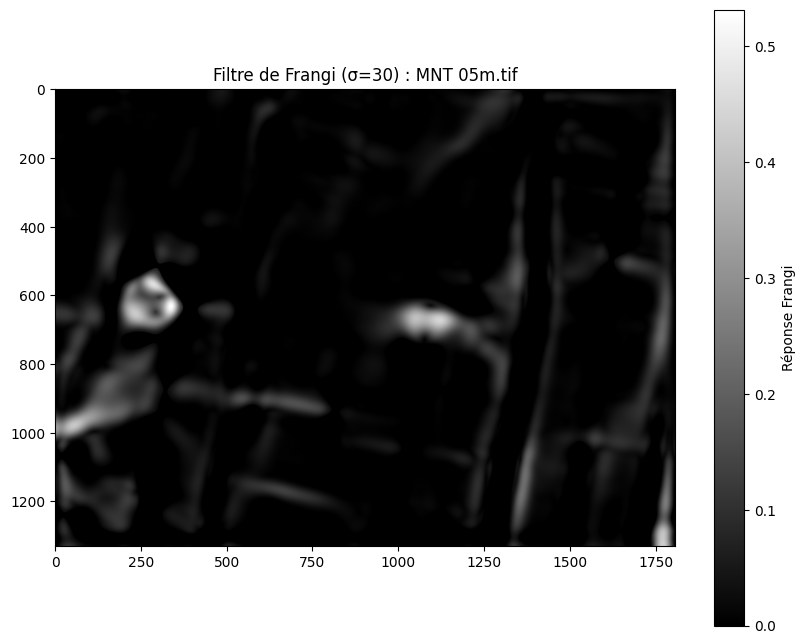

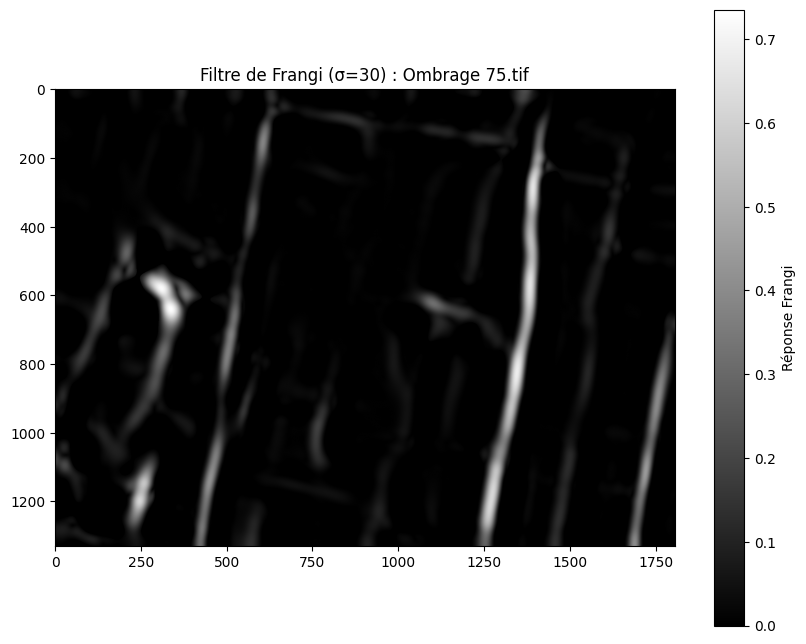

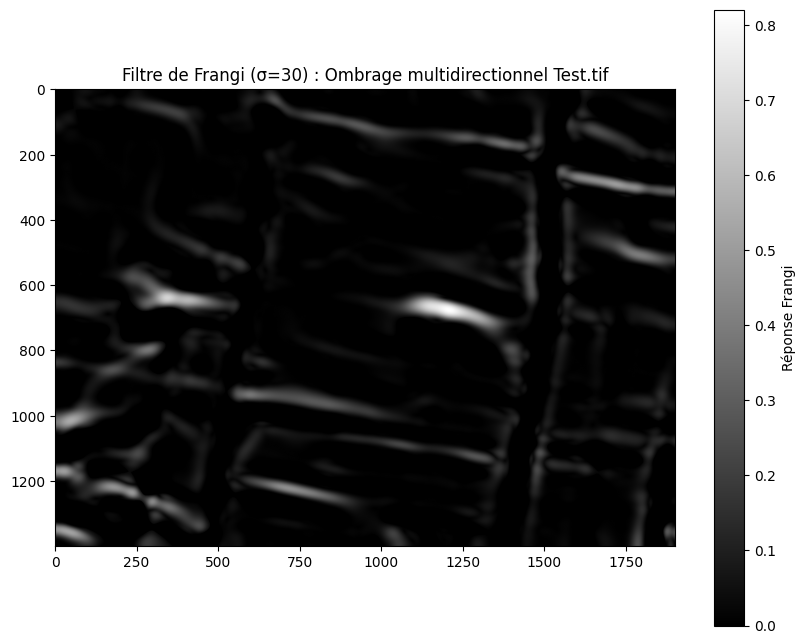

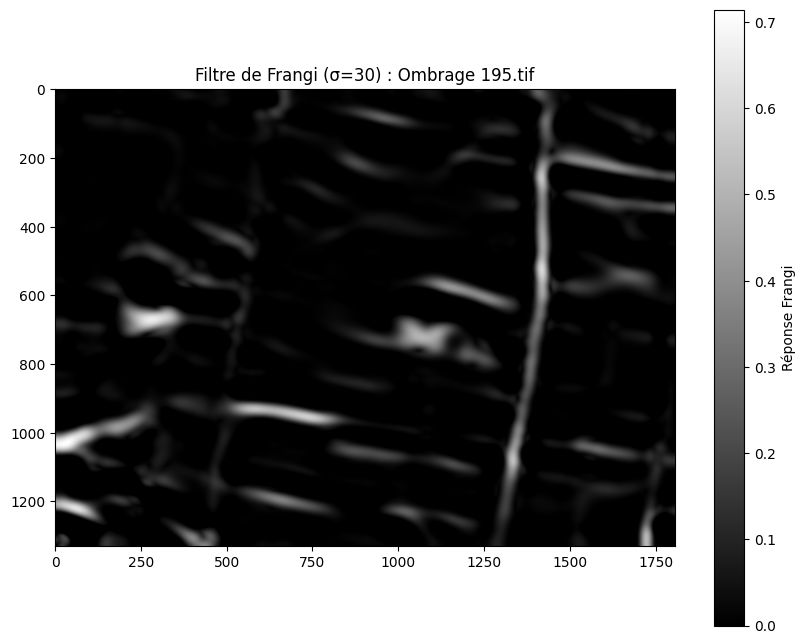

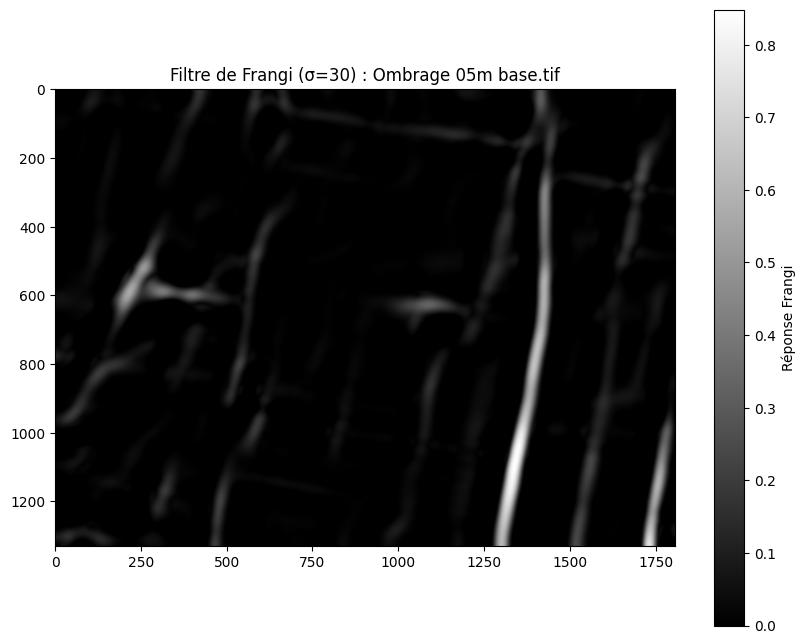

In [12]:
from skimage.filters import frangi
import rasterio
import matplotlib.pyplot as plt
import os

# Paramètre demandé
σ = 30

# Chemin vers le dossier (défini précédemment)
folder_path = '/content/drive/MyDrive/Datasets/Gauthier_Cerema/Premier_test'
tif_files = [f for f in os.listdir(folder_path) if f.endswith('.tif')]

print(f"Calcul du filtre de Frangi avec σ = {σ} ...\n")

for file_name in tif_files:
    file_path = os.path.join(folder_path, file_name)

    try:
        with rasterio.open(file_path) as src:
            # Lecture de la bande 1
            data = src.read(1)

            # Application du filtre de Frangi
            # sigmas attend une liste d'échelles
            response = frangi(data, sigmas=[σ])

            plt.figure(figsize=(10, 8))
            plt.imshow(response, cmap='gray')
            plt.colorbar(label='Réponse Frangi')
            plt.title(f"Filtre de Frangi (σ={σ}) : {file_name}")
            plt.axis('on')
            plt.show()

    except Exception as e:
        print(f"Erreur sur {file_name} : {e}")